# Анализ тональности текста: русскоязычные отзывы и предобученные эмбеддинги

Практическая работа № 5 по дисциплине «Методы машинного обучения».
Московский Политех, группа 231-329, Арутюнян Ф. Р.

**Как я понял задачу.** Текста задания в СДО нет. Работа парная к лабораторной № 2, где я
разбирал англоязычные отзывы IMDB мешком слов и рекуррентной сетью. Здесь беру другой корпус,
русскоязычные рецензии с Кинопоиска, и другой метод, предобученные векторные представления слов,
а в конце сравниваю результат с лабораторной № 2.

**Данные.** Набор `blinoff/kinopoisk` с Hugging Face: 36 591 рецензия с фильмами из топ-250
и худшей сотни, у каждой рецензии оценка автора Good, Neutral или Bad.

**Метод.** Предобученные эмбеддинги Navec из проекта Natasha: 500 002 слова, вектор длиной 300,
обучены на художественных текстах. Отзыв превращается в один вектор усреднением векторов его слов.
Для сравнения на том же корпусе обучаю TF-IDF с логистической регрессией, как в лабораторной № 2.

**Чем эмбеддинги отличаются от мешка слов.** В мешке слов каждое слово это отдельная колонка,
и «ужасный» с «отвратительный» для модели никак не связаны. В эмбеддингах близкие по смыслу слова
имеют близкие векторы, потому что их обучали по соседству слов в больших текстах. Кроме того,
вектор отзыва занимает 300 чисел вместо 20 000.

## 0. Библиотеки и настройки

In [1]:
import os
import re
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from navec import Navec
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, roc_curve, classification_report)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

FIG_DIR = 'figures'
os.makedirs(FIG_DIR, exist_ok=True)
RANDOM_STATE = 42


def save_fig(name):
    plt.savefig(os.path.join(FIG_DIR, name), dpi=150, bbox_inches='tight')

## 1. Корпус отзывов

Файл `kinopoisk.jsonl` скачивается с Hugging Face при первом запуске, эмбеддинги Navec
с сервера проекта Natasha.

In [2]:
import urllib.request

os.makedirs('data', exist_ok=True)
SOURCES = {
    'data/kinopoisk.jsonl': 'https://huggingface.co/datasets/blinoff/kinopoisk/resolve/main/kinopoisk.jsonl',
    'data/navec_hudlit.tar': 'https://storage.yandexcloud.net/natasha-navec/packs/navec_hudlit_v1_12B_500K_300d_100q.tar',
}
for path, url in SOURCES.items():
    if not os.path.exists(path):
        print('качаю', path)
        urllib.request.urlretrieve(url, path)

raw = pd.read_json('data/kinopoisk.jsonl', lines=True)
print('Всего рецензий:', len(raw))
print(raw['grade3'].value_counts().to_dict())
raw[['movie_name', 'grade3', 'grade10', 'content']].head(3)

Всего рецензий: 36591
{'Good': 27264, 'Bad': 4751, 'Neutral': 4576}


,movie_name,grade3,grade10,content
0,Блеф (1976),Good,10.0,"\n""Блеф» — одна из моих самых любимых комедий...."
1,Блеф (1976),Good,0.0,\nАдриано Челентано продолжает радовать нас св...
2,Блеф (1976),Good,10.0,"\nНесомненно, это один из великих фильмов 80-х..."


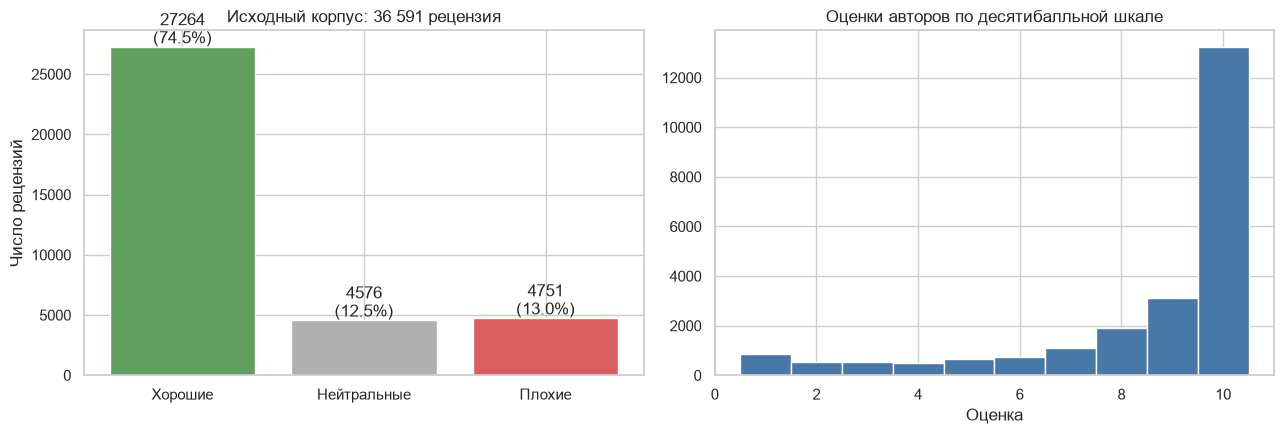

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
vc = raw['grade3'].value_counts()
axes[0].bar(['Хорошие', 'Нейтральные', 'Плохие'],
            [vc['Good'], vc['Neutral'], vc['Bad']], color=['#5fa05f', '#b0b0b0', '#d95f5f'])
for i, v in enumerate([vc['Good'], vc['Neutral'], vc['Bad']]):
    axes[0].text(i, v + 300, f'{v}\n({v / len(raw):.1%})', ha='center')
axes[0].set_title('Исходный корпус: 36 591 рецензия')
axes[0].set_ylabel('Число рецензий')

g10 = raw['grade10'].astype(str).str.extract(r'(\d+)')[0].astype(float)
axes[1].hist(g10.dropna(), bins=10, range=(0.5, 10.5), color='#4878a8', edgecolor='white')
axes[1].set_title('Оценки авторов по десятибалльной шкале')
axes[1].set_xlabel('Оценка')
fig.tight_layout()
save_fig('01_corpus.png')
plt.show()

**Рисунок 1 — Состав исходного корпуса**

Корпус сильно перекошен: хороших рецензий 27 264 (74,5 %), плохих 4751 (13,0 %), нейтральных 4576, а по десятибалльной шкале чаще всего встречаются оценки 8, 9 и 10.

Нейтральные рецензии убираю: задача бинарная, как в лабораторной № 2. Классы в корпусе
сильно несбалансированы, плохих рецензий в пять с лишним раз меньше, поэтому беру
все плохие и столько же случайных хороших. Так accuracy остаётся честной метрикой,
и результат сравним с лабораторной № 2, где классы тоже были поровну.

In [4]:
binary = raw[raw['grade3'].isin(['Good', 'Bad'])].copy()
n_bad = (binary['grade3'] == 'Bad').sum()

bad = binary[binary['grade3'] == 'Bad']
good = binary[binary['grade3'] == 'Good'].sample(n_bad, random_state=RANDOM_STATE)
df = pd.concat([bad, good]).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
df['label'] = (df['grade3'] == 'Good').astype(int)

print('Выборка для работы:', len(df))
print(df['grade3'].value_counts().to_dict())
df['n_words'] = df['content'].str.split().str.len()
print(df.groupby('grade3')['n_words'].describe().round(1)[['mean', '50%', 'max']])

Выборка для работы: 9502
{'Good': 4751, 'Bad': 4751}


         mean    50%     max
grade3                      
Bad     307.1  259.0  1111.0
Good    299.2  250.0  2209.0


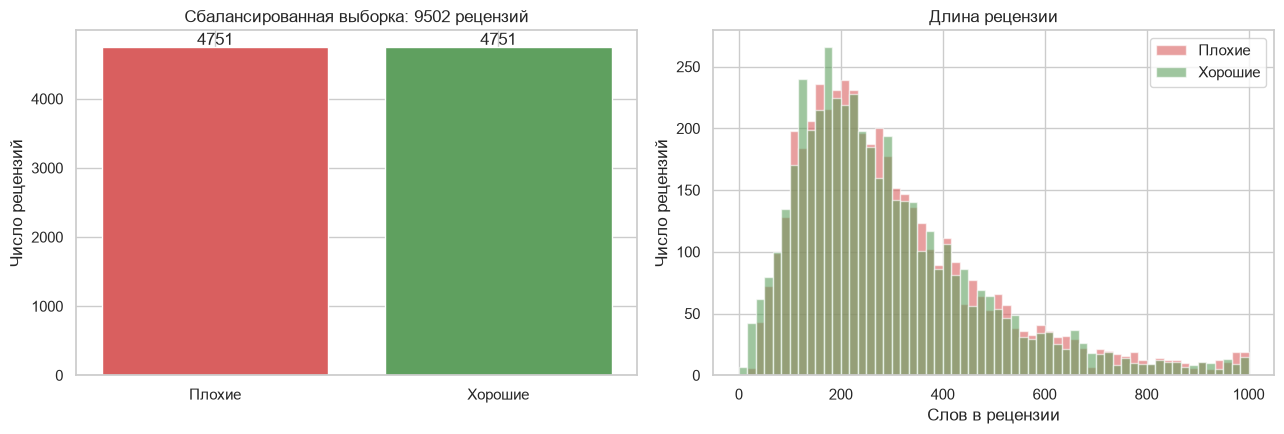

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
counts = df['grade3'].value_counts()
axes[0].bar(['Плохие', 'Хорошие'], [counts['Bad'], counts['Good']], color=['#d95f5f', '#5fa05f'])
for i, v in enumerate([counts['Bad'], counts['Good']]):
    axes[0].text(i, v + 30, str(v), ha='center')
axes[0].set_title(f'Сбалансированная выборка: {len(df)} рецензий')
axes[0].set_ylabel('Число рецензий')

for label, color, name in [(0, '#d95f5f', 'Плохие'), (1, '#5fa05f', 'Хорошие')]:
    axes[1].hist(df[df['label'] == label]['n_words'], bins=60, range=(0, 1000),
                 alpha=0.6, color=color, label=name)
axes[1].set_xlabel('Слов в рецензии')
axes[1].set_ylabel('Число рецензий')
axes[1].set_title('Длина рецензии')
axes[1].legend()
fig.tight_layout()
save_fig('02_sample.png')
plt.show()

**Рисунок 2 — Сбалансированная выборка и длина рецензий**

После балансировки в выборке по 4751 рецензии каждого класса, длина у классов почти одинаковая: медиана 259 слов у плохих и 250 у хороших.

## 2. Предобработка

Русский текст отличается от английского тем, что у слова много форм: «скучный», «скучная»,
«скучные». Лемматизацию не делаю, потому что словарь Navec содержит именно словоформы,
и вектор находится для большинства из них. Что делаю:
- перевожу в нижний регистр;
- убираю всё, кроме кириллицы, дефиса и пробелов;
- склеиваю повторяющиеся пробелы.

In [6]:
NON_CYR = re.compile(r'[^а-яё\- ]')


def clean(text):
    text = str(text).lower().replace('ё', 'е')
    text = NON_CYR.sub(' ', text)
    return ' '.join(text.split())


t0 = time.time()
df['clean'] = df['content'].apply(clean)
print(f'очистка заняла {time.time() - t0:.1f} с')
print('До:', df.loc[0, 'content'][:180].replace('\n', ' '))
print('\nПосле:', df.loc[0, 'clean'][:180])

очистка заняла 0.5 с
До:  В детстве я мечтала посмотреть фильм «День сурка». Я слышала о нем, читала о нем, видела, что его часто показывают (по программе телепередач), но… у меня никак не получалось попас

После: в детстве я мечтала посмотреть фильм день сурка я слышала о нем читала о нем видела что его часто показывают по программе телепередач но у меня никак не получалось попасть на него 


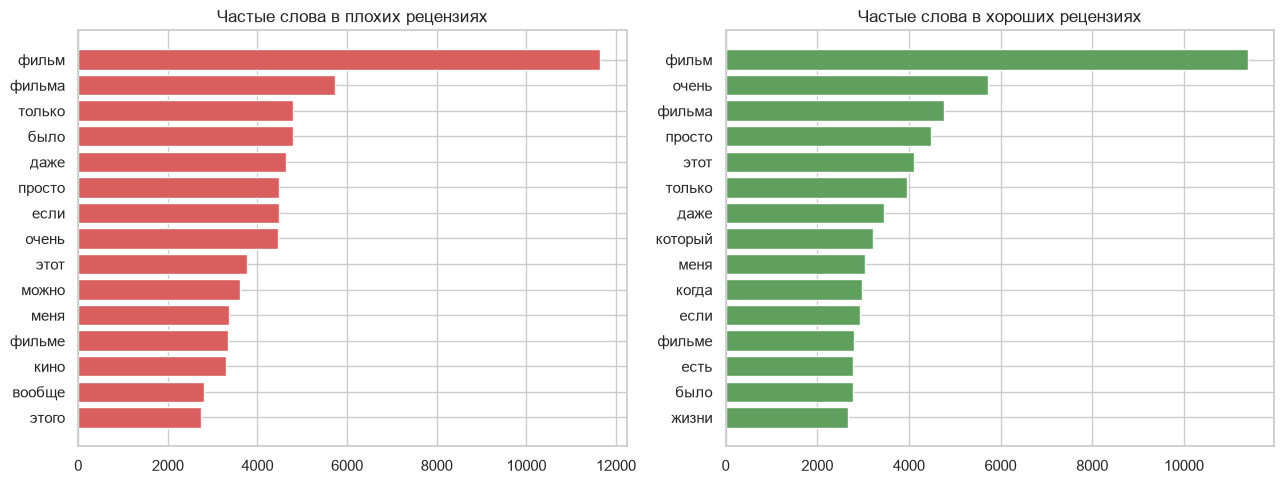

In [7]:
from collections import Counter

def top_words(texts, n=15, min_len=4):
    c = Counter(w for t in texts for w in t.split() if len(w) >= min_len)
    return pd.Series(dict(c.most_common(n)))


top_good = top_words(df[df['label'] == 1]['clean'])
top_bad = top_words(df[df['label'] == 0]['clean'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].barh(top_bad.index[::-1], top_bad.values[::-1], color='#d95f5f')
axes[0].set_title('Частые слова в плохих рецензиях')
axes[1].barh(top_good.index[::-1], top_good.values[::-1], color='#5fa05f')
axes[1].set_title('Частые слова в хороших рецензиях')
fig.tight_layout()
save_fig('03_top_words.png')
plt.show()

**Рисунок 3 — Частые слова по классам**

Верх частотности у обоих классов занимают нейтральные слова (фильм, фильма, только, просто), у хороших рецензий выше стоит очень, у плохих можно и вообще, то есть по частотам классы почти не различаются.

## 3. Предобученные эмбеддинги Navec

Navec это сжатые векторные представления слов из проекта Natasha. Каждому из 500 002 слов
сопоставлен вектор длиной 300. Векторы обучены так, что слова, встречающиеся в похожих
контекстах, оказываются рядом в пространстве.

Проверяю на паре слов, что расстояния осмысленные, и смотрю, какая доля слов моего корпуса
нашлась в словаре Navec.

In [8]:
navec = Navec.load('data/navec_hudlit.tar')
print('Слов в словаре Navec:', len(navec.vocab.words))


def similar(word, n=6):
    v = navec[word]
    mat = navec.pq.unpack()
    sims = mat @ v / (np.linalg.norm(mat, axis=1) * np.linalg.norm(v) + 1e-9)
    idx = np.argsort(-sims)[1:n + 1]
    return [(navec.vocab.words[i], round(float(sims[i]), 3)) for i in idx]


for w in ['скучный', 'шедевр', 'актер']:
    print(f'{w}: {similar(w)}')

Слов в словаре Navec: 500002


скучный: [('унылый', 0.716), ('нудный', 0.686), ('неинтересный', 0.66), ('занудный', 0.618), ('однообразный', 0.618), ('безрадостный', 0.585)]


шедевр: [('шедевры', 0.66), ('шедевром', 0.637), ('произведение', 0.598), ('шедевра', 0.553), ('шедевров', 0.55), ('искусства', 0.533)]


актер: [('артист', 0.778), ('режиссер', 0.749), ('певец', 0.64), ('актёр', 0.635), ('сценарист', 0.62), ('комик', 0.614)]


Разных слов в корпусе: 154147, из них есть в Navec: 121472 (78.8%)
Покрытие по всем словоупотреблениям: 98.0%

Самые частые слова без вектора:
-             2031
дикаприо       363
-х             352
хатико         263
галустян       180
леджера        147
экшена         132
макадамс       123
шоушенка       122
заворотнюк     113
dtype: int64


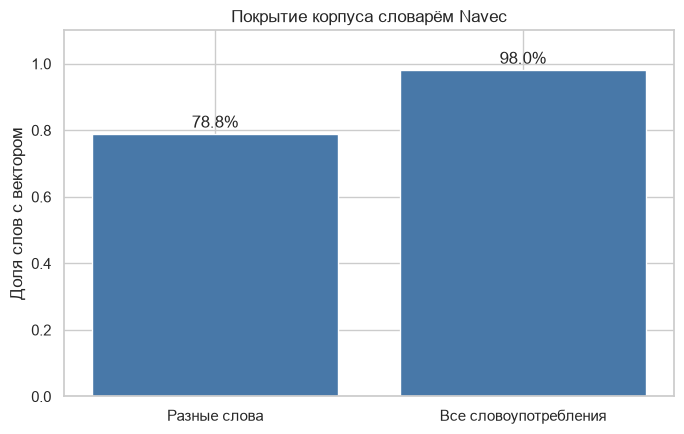

In [9]:
# доля слов корпуса, для которых есть вектор
all_words = Counter(w for t in df['clean'] for w in t.split())
known = {w: c for w, c in all_words.items() if w in navec.vocab}
coverage_types = len(known) / len(all_words)
coverage_tokens = sum(known.values()) / sum(all_words.values())
print(f'Разных слов в корпусе: {len(all_words)}, из них есть в Navec: {len(known)} ({coverage_types:.1%})')
print(f'Покрытие по всем словоупотреблениям: {coverage_tokens:.1%}')

missing = pd.Series({w: c for w, c in all_words.items() if w not in navec.vocab}).nlargest(10)
print('\nСамые частые слова без вектора:')
print(missing)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(['Разные слова', 'Все словоупотребления'], [coverage_types, coverage_tokens], color='#4878a8')
for i, v in enumerate([coverage_types, coverage_tokens]):
    ax.text(i, v + 0.02, f'{v:.1%}', ha='center')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Доля слов с вектором')
ax.set_title('Покрытие корпуса словарём Navec')
fig.tight_layout()
save_fig('04_coverage.png')
plt.show()

**Рисунок 4 — Покрытие корпуса словарём Navec**

Вектор нашёлся у 78,8 % разных слов корпуса и у 98,0 % всех словоупотреблений: без вектора остаются в основном фамилии актёров и названия фильмов вроде дикаприо и хатико.

In [10]:
# вектор отзыва это среднее векторов его слов
def embed(text):
    vecs = [navec[w] for w in text.split() if w in navec.vocab]
    if not vecs:
        return np.zeros(300, dtype=np.float32)
    return np.mean(vecs, axis=0)


t0 = time.time()
X_emb = np.vstack([embed(t) for t in df['clean']])
print(f'векторизация заняла {time.time() - t0:.0f} с, форма матрицы {X_emb.shape}')

векторизация заняла 12 с, форма матрицы (9502, 300)


Две компоненты объясняют 23.7% дисперсии


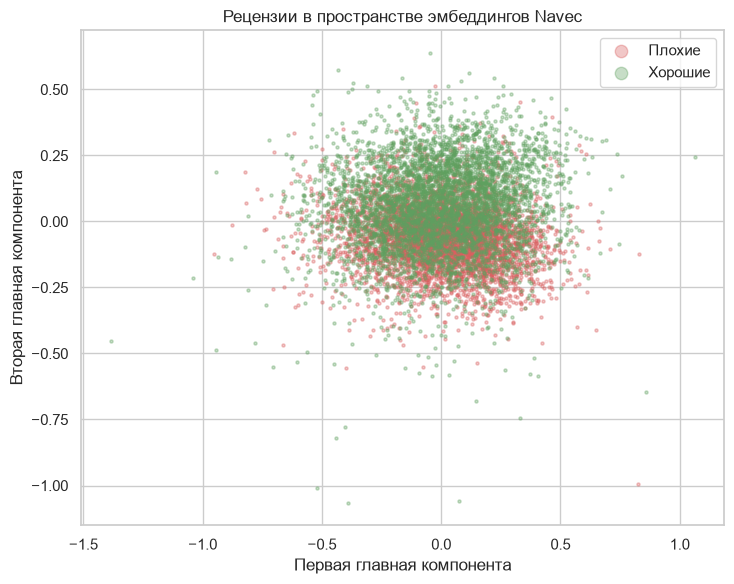

In [11]:
# как классы выглядят в пространстве эмбеддингов
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_emb)
print(f'Две компоненты объясняют {pca.explained_variance_ratio_.sum():.1%} дисперсии')

fig, ax = plt.subplots(figsize=(7.5, 6))
for label, color, name in [(0, '#d95f5f', 'Плохие'), (1, '#5fa05f', 'Хорошие')]:
    mask = df['label'].values == label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=5, alpha=0.35, color=color, label=name)
ax.set_xlabel('Первая главная компонента')
ax.set_ylabel('Вторая главная компонента')
ax.set_title('Рецензии в пространстве эмбеддингов Navec')
ax.legend(markerscale=4)
fig.tight_layout()
save_fig('05_pca.png')
plt.show()

**Рисунок 5 — Проекция векторов рецензий на две главные компоненты**

Облака классов сильно перекрываются, плохие рецензии лишь немного смещены вниз, при этом две компоненты объясняют только 23,7 % дисперсии, поэтому по такой картинке разделимость оценивать рано.

## 4. Обучение и сравнение методов

Разбиение 75 / 25 со стратификацией, как в лабораторной № 2. Обучаю логистическую регрессию
на двух представлениях: TF-IDF (как в лабораторной) и усреднённые эмбеддинги Navec.

In [12]:
idx_train, idx_test = train_test_split(
    np.arange(len(df)), test_size=0.25, stratify=df['label'], random_state=RANDOM_STATE)
y_train, y_test = df['label'].values[idx_train], df['label'].values[idx_test]
print(f'Обучение {len(idx_train)}, тест {len(idx_test)}')

results, proba = [], {}


def add_result(name, p):
    pred = (p > 0.5).astype(int)
    proba[name] = p
    results.append({
        'Метод': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, p),
    })


tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))
X_tr_tfidf = tfidf.fit_transform(df['clean'].values[idx_train])
X_te_tfidf = tfidf.transform(df['clean'].values[idx_test])
lr_tfidf = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE).fit(X_tr_tfidf, y_train)
add_result('TF-IDF + логрегрессия', lr_tfidf.predict_proba(X_te_tfidf)[:, 1])

lr_emb = LogisticRegression(max_iter=3000, random_state=RANDOM_STATE).fit(X_emb[idx_train], y_train)
add_result('Navec + логрегрессия', lr_emb.predict_proba(X_emb[idx_test])[:, 1])

res_df = pd.DataFrame(results).set_index('Метод').sort_values('Accuracy', ascending=False)
res_df.round(4)

Обучение 7126, тест 2376


,Accuracy,Precision,Recall,F1,ROC-AUC
Метод,,,,,
TF-IDF + логрегрессия,0.9221,0.9218,0.9226,0.9222,0.9746
Navec + логрегрессия,0.8906,0.9000,0.8788,0.8893,0.9595


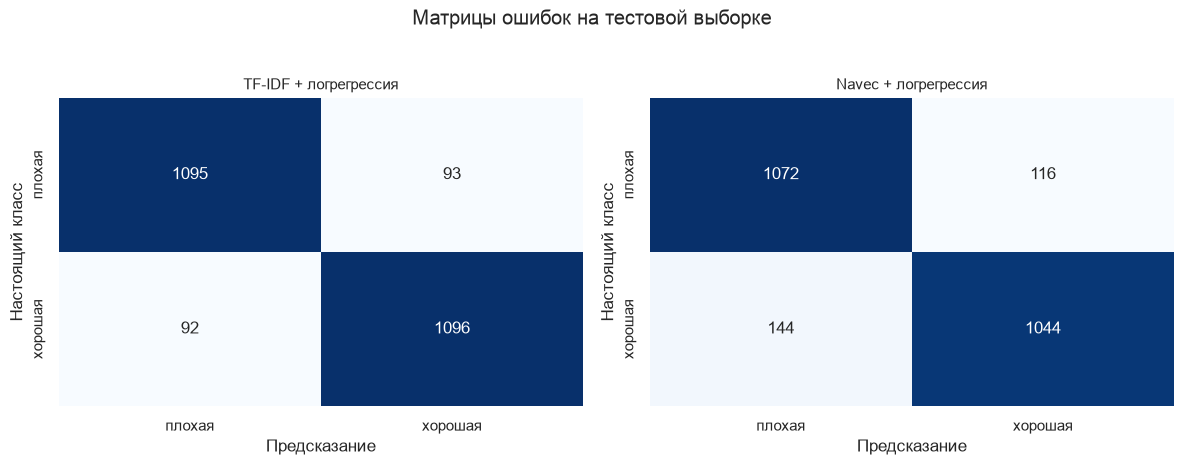

TF-IDF + логрегрессия     плохая названа хорошей:   93, хорошая названа плохой:   92
Navec + логрегрессия      плохая названа хорошей:  116, хорошая названа плохой:  144


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, name in zip(axes, proba):
    cm = confusion_matrix(y_test, (proba[name] > 0.5).astype(int))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['плохая', 'хорошая'], yticklabels=['плохая', 'хорошая'])
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Предсказание')
    ax.set_ylabel('Настоящий класс')
fig.suptitle('Матрицы ошибок на тестовой выборке', y=1.03)
fig.tight_layout()
save_fig('06_confusion.png')
plt.show()

for name in proba:
    tn, fp, fn, fnn = confusion_matrix(y_test, (proba[name] > 0.5).astype(int)).ravel()
    print(f'{name:25} плохая названа хорошей: {fp:4}, хорошая названа плохой: {fn:4}')

**Рисунок 6 — Матрицы ошибок двух методов**

TF-IDF ошибается 185 раз из 2376 почти поровну в обе стороны (93 и 92), Navec 260 раз и чаще принимает хорошую рецензию за плохую (144 против 116).

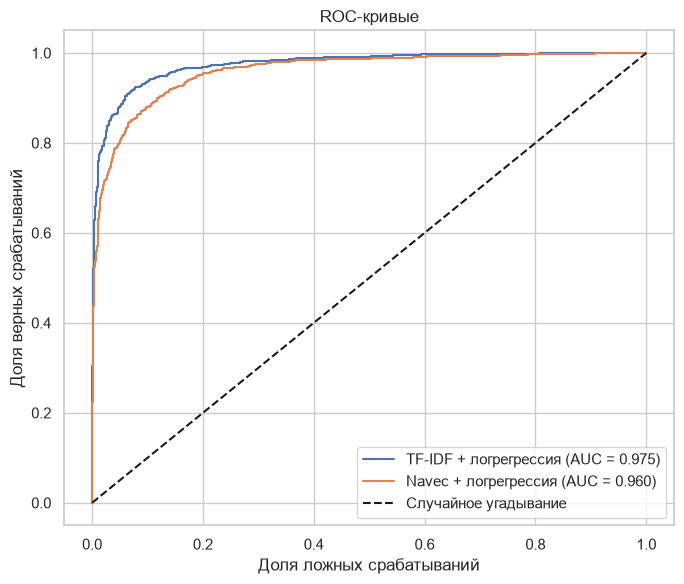

In [14]:
fig, ax = plt.subplots(figsize=(7, 6))
for name in proba:
    fpr, tpr, _ = roc_curve(y_test, proba[name])
    ax.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_test, proba[name]):.3f})')
ax.plot([0, 1], [0, 1], 'k--', label='Случайное угадывание')
ax.set_xlabel('Доля ложных срабатываний')
ax.set_ylabel('Доля верных срабатываний')
ax.set_title('ROC-кривые')
ax.legend()
fig.tight_layout()
save_fig('07_roc.png')
plt.show()

**Рисунок 7 — ROC-кривые двух методов**

ROC-AUC у TF-IDF 0,975 против 0,960 у эмбеддингов, обе кривые прижаты к левому верхнему углу.

## 5. Сравнение с лабораторной работой № 2

В лабораторной № 2 тот же подход TF-IDF с логистической регрессией на англоязычных отзывах IMDB
дал accuracy 0,8736 и ROC-AUC 0,9437, а рекуррентная сеть LSTM accuracy 0,7396 и ROC-AUC 0,8072.
Корпуса разные по языку, объёму и стилю, поэтому сравнение приблизительное.

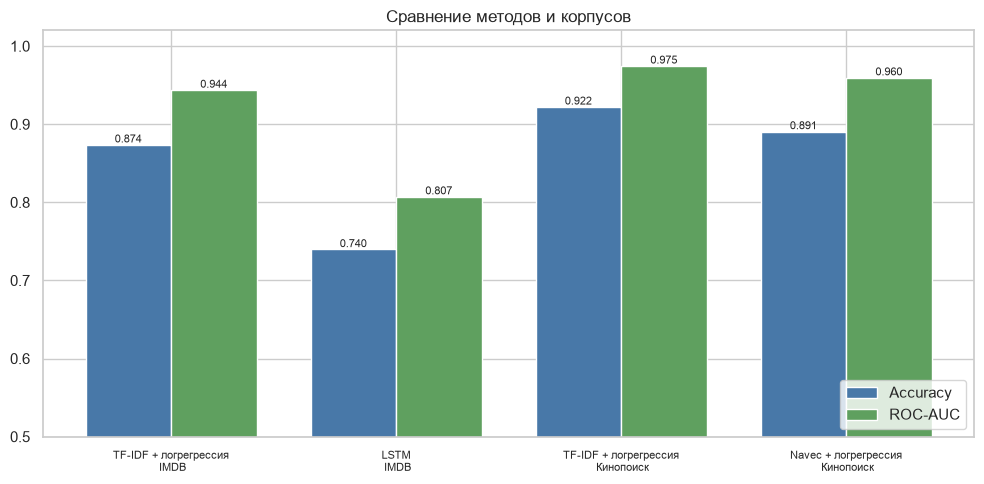

,Работа,Метод,Accuracy,ROC-AUC
0,"ЛР2, IMDB, английский",TF-IDF + логрегрессия,0.8736,0.9437
1,"ЛР2, IMDB, английский",LSTM,0.7396,0.8072
2,"ПР5, Кинопоиск, русский",TF-IDF + логрегрессия,0.9221,0.9746
3,"ПР5, Кинопоиск, русский",Navec + логрегрессия,0.8906,0.9595


In [15]:
lab2 = pd.DataFrame({
    'Работа': ['ЛР2, IMDB, английский', 'ЛР2, IMDB, английский', 'ПР5, Кинопоиск, русский', 'ПР5, Кинопоиск, русский'],
    'Метод': ['TF-IDF + логрегрессия', 'LSTM', 'TF-IDF + логрегрессия', 'Navec + логрегрессия'],
    'Accuracy': [0.8736, 0.7396, res_df.loc['TF-IDF + логрегрессия', 'Accuracy'],
                 res_df.loc['Navec + логрегрессия', 'Accuracy']],
    'ROC-AUC': [0.9437, 0.8072, res_df.loc['TF-IDF + логрегрессия', 'ROC-AUC'],
                res_df.loc['Navec + логрегрессия', 'ROC-AUC']],
})

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(lab2))
width = 0.38
b1 = ax.bar(x - width / 2, lab2['Accuracy'], width, label='Accuracy', color='#4878a8')
b2 = ax.bar(x + width / 2, lab2['ROC-AUC'], width, label='ROC-AUC', color='#5fa05f')
ax.bar_label(b1, fmt='%.3f', fontsize=8)
ax.bar_label(b2, fmt='%.3f', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels([f"{m}\n{w.split(',')[1]}" for m, w in zip(lab2['Метод'], lab2['Работа'])], fontsize=8)
ax.set_ylim(0.5, 1.02)
ax.set_title('Сравнение методов и корпусов')
ax.legend(loc='lower right')
fig.tight_layout()
save_fig('08_comparison.png')
plt.show()

lab2.round(4)

**Рисунок 8 — Сравнение методов на двух корпусах**

На русском корпусе обе модели работают лучше, чем на IMDB: TF-IDF 0,922 против 0,874, а усреднённые эмбеддинги Navec (0,891) обходят обученную с нуля LSTM из лабораторной № 2 (0,740) на 15 процентных пунктов.

In [16]:
best_name = res_df.index[0]
best_pred = (proba[best_name] > 0.5).astype(int)
print('Лучший метод:', best_name, '\n')
print(classification_report(y_test, best_pred, target_names=['плохие', 'хорошие'], digits=4))

summary = pd.DataFrame({
    'Вся выборка': df['label'].value_counts().sort_index().values,
    'Тестовая часть': pd.Series(y_test).value_counts().sort_index().values,
    f'Предсказано ({best_name})': pd.Series(best_pred).value_counts().sort_index().values,
}, index=['Плохие', 'Хорошие'])
summary.loc['Всего'] = summary.sum()
summary

Лучший метод: TF-IDF + логрегрессия 

              precision    recall  f1-score   support

      плохие     0.9225    0.9217    0.9221      1188
     хорошие     0.9218    0.9226    0.9222      1188

    accuracy                         0.9221      2376
   macro avg     0.9221    0.9221    0.9221      2376
weighted avg     0.9221    0.9221    0.9221      2376



,Вся выборка,Тестовая часть,Предсказано (TF-IDF + логрегрессия)
Плохие,4751,1188,1187
Хорошие,4751,1188,1189
Всего,9502,2376,2376


In [17]:
# две рецензии, на которых лучший метод ошибся
errors = np.where(best_pred != y_test)[0][:2]
for k in errors:
    row = df.iloc[idx_test[k]]
    print(f"\nфильм: {row['movie_name']}, оценка автора {row['grade10']} ({row['grade3']}), "
          f"вероятность хорошей {proba[best_name][k]:.2f}")
    print(row['content'][:350].replace('\n', ' '), '...')


фильм: Темный рыцарь (2008), оценка автора 7.0 (Bad), вероятность хорошей 0.71
 Готэм-сити. Неблагополучный город контролируют мафиози с которыми усердно борется комиссар Гордон, прокурор Харви Дент и тёмный рыцарь Бэтман. Преступник по имени Джокер, который то сотрудничает с мафией, то крадёт у них деньги, предлагает авторитетам преступного мира уничтожить Бэтмана и прокурора. Между Рыцарем Мрака и Джокером завязывается войн ...

фильм: Спасти рядового Райана (1998), оценка автора 0.0 (Bad), вероятность хорошей 0.56
 Этот фильм я не смог досмотреть до конца. Спасти рядового Райана — неимоверно напряжённый и жестокий фильм. Время от времени становится просто жутко, трясётся экран (из-за этого вообще некоторые сцены трудно воспринять), слышны панические вопли раненых, и начинаешь осознавать насколько страшна война. Я бы рекомендовал отнести этот фильм к категори ...


## 6. Выводы

1. **Корпус.** Рецензии с Кинопоиска, 36 591 штука. Нейтральные убраны, классы выровнены:
   4751 плохая и 4751 хорошая рецензия, всего 9502. Тест 2376 рецензий.

2. **Предобученные эмбеддинги работают сразу.** Navec покрывает 98,0 % словоупотреблений корпуса,
   без вектора остаются фамилии актёров и названия фильмов. Усреднение векторов слов даёт
   на рецензию 300 чисел вместо 20 000 колонок мешка слов, и логистическая регрессия на них
   даёт accuracy 0,8906, precision 0,9000, recall 0,8788, F1 0,8893, ROC-AUC 0,9595.

3. **TF-IDF всё равно лучше:** accuracy 0,9221, F1 0,9222, ROC-AUC 0,9746, ошибок 185 против 260.
   Усреднение теряет информацию: вектор рецензии из 300 слов это среднее 300 векторов,
   и отдельное «отвратительно» растворяется среди нейтральных слов. TF-IDF, наоборот,
   даёт редкому оценочному слову большой вес.

4. **Сравнение с лабораторной № 2.** Там на англоязычном IMDB TF-IDF дал 0,8736, а обученная с нуля
   LSTM 0,7396. Здесь тот же TF-IDF даёт 0,9221, а предобученные эмбеддинги 0,8906. Вывод по методам:
   предобученные векторы обходят обучение векторов с нуля на 15 процентных пунктов, но простой
   мешок слов с правильным взвешиванием остаётся сильным базовым решением для задачи тональности.

5. **Почему на русском корпусе точность выше.** Рецензии Кинопоиска длиннее (медиана 250 слов
   против 174 у IMDB), и взяты они с полюсов: фильмы из топ-250 и из худшей сотни, поэтому
   тональность выражена ярче. Разница в языке здесь ни при чём.

6. **Шум в разметке.** Среди ошибок попадаются рецензии, помеченные как плохие при оценке автора
   7 из 10: метка grade3 ставится самим автором и не всегда согласуется с его же баллом.
   Часть ошибок модели объясняется именно этим.

7. **Что улучшило бы результат:** взвешивание векторов слов по TF-IDF вместо простого усреднения,
   лемматизация для русского языка, дообучение модели вроде ruBERT, объединение признаков
   TF-IDF и эмбеддингов в одну модель.